# Analyse Input for Spatial Distribution

Graphs to decide what spacial regions should be picked

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

In [4]:
# === Load dataset ===
ds = xr.open_dataset("../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc")

## Geopotential + Wind Speed at 300 and 850 hPa

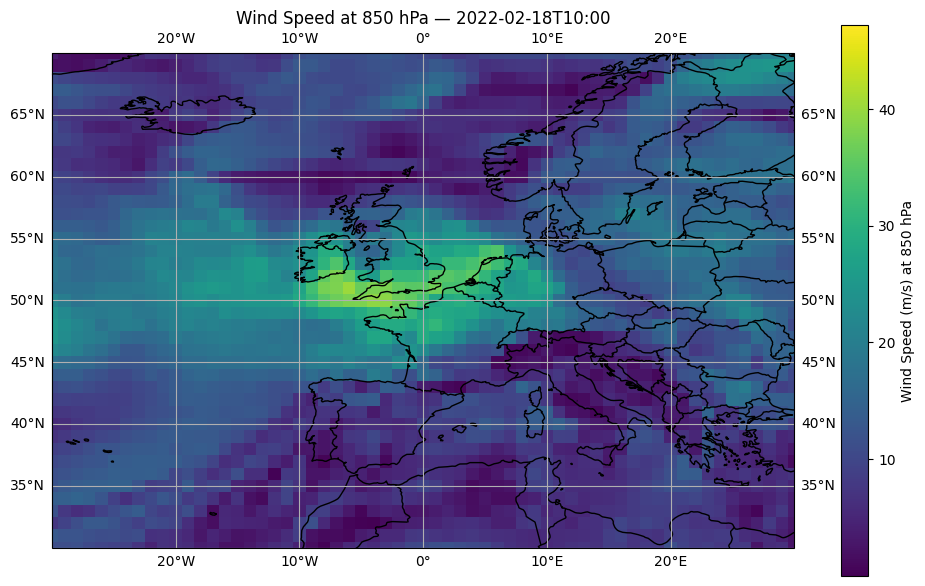

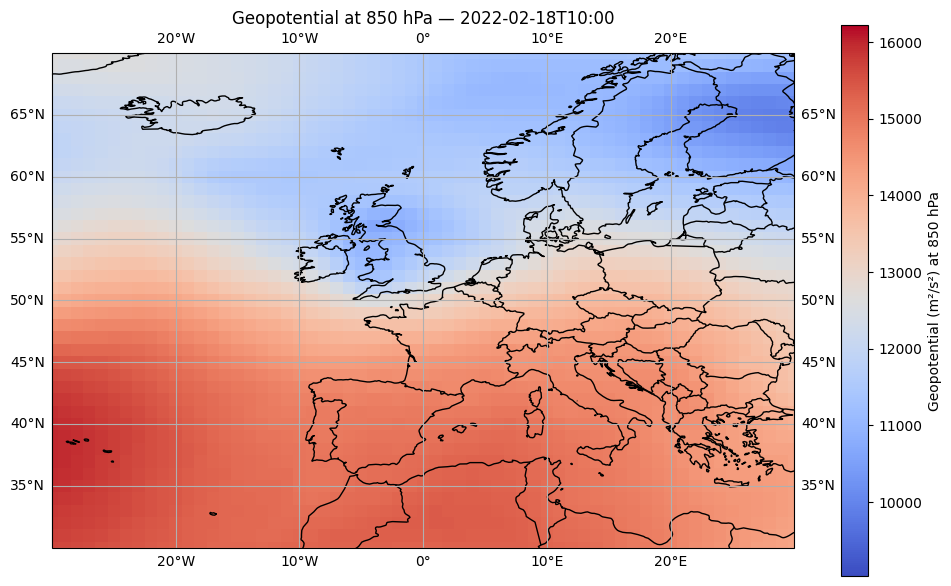

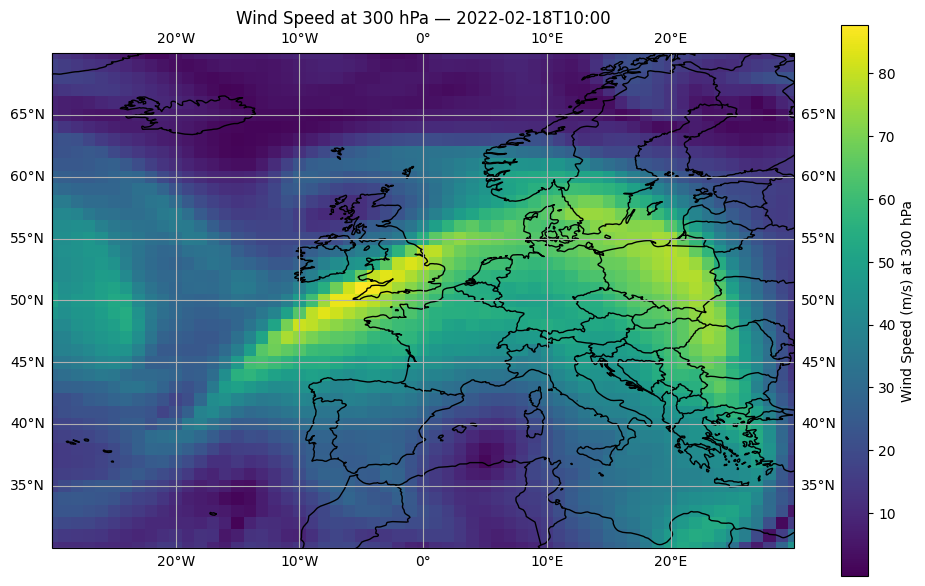

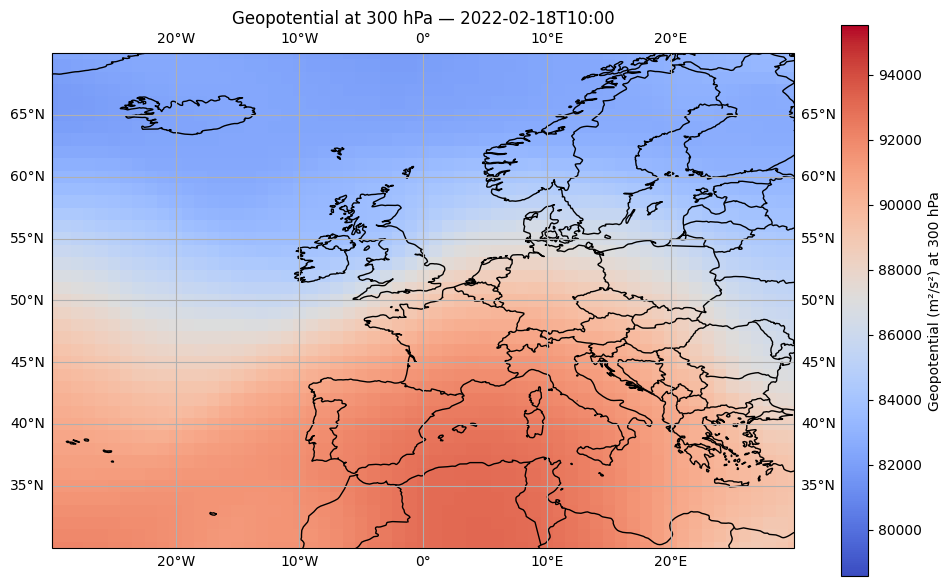

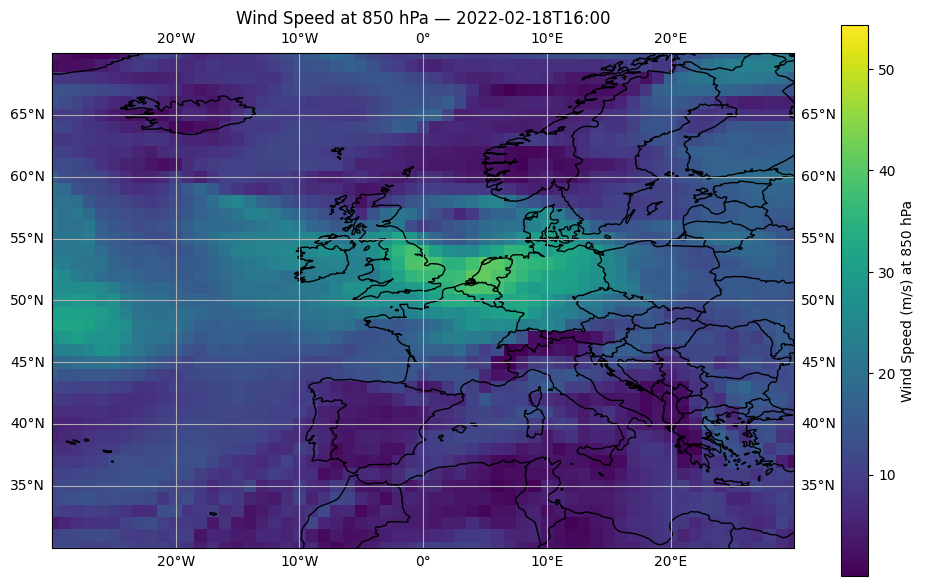

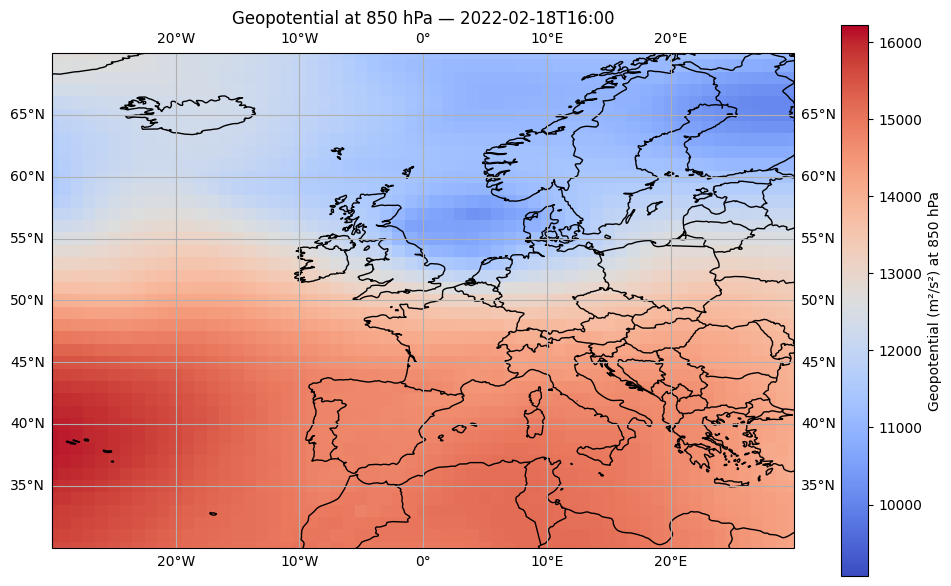

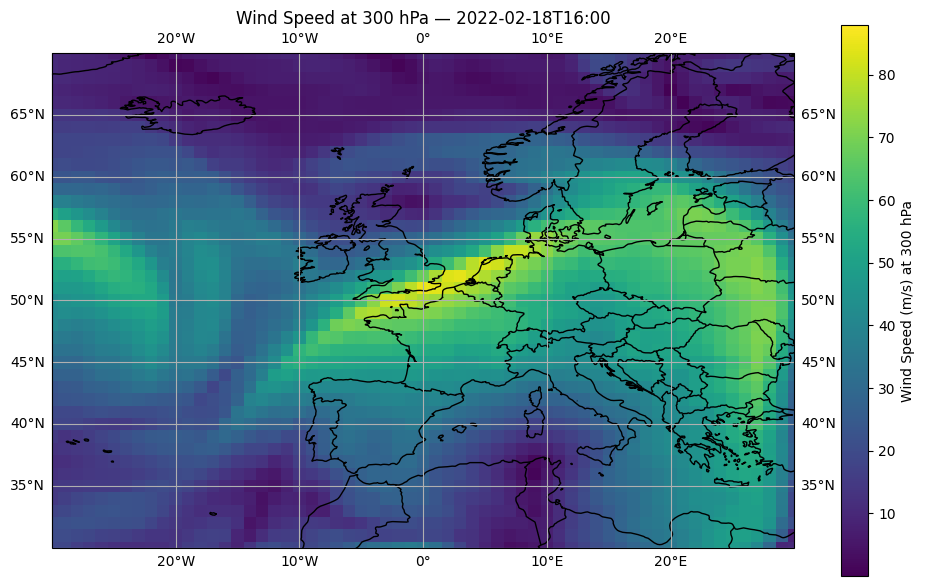

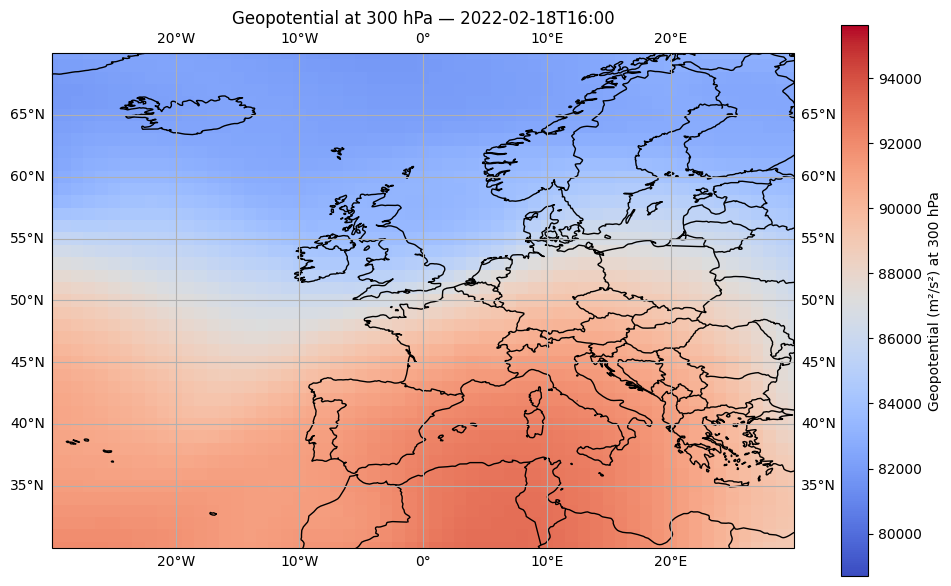

In [3]:
# === Define parameters ===
levels = [850, 300]
times = [0, 1]  # 0 = 09:00 UTC, 1 = 15:00 UTC
zoom_extent = [-30, 30, 30, 70]  # Europe region

for time_idx in times:
    for level in levels:
        # === Wind Speed ===
        u = ds["u_component_of_wind"].sel(time=ds.time[time_idx], level=level)
        v = ds["v_component_of_wind"].sel(time=ds.time[time_idx], level=level)
        wind_speed = np.sqrt(u**2 + v**2)

        plt.figure(figsize=(10, 6))
        ax = plt.axes(projection=ccrs.PlateCarree())
        wind_speed.plot(ax=ax, cmap="viridis", cbar_kwargs={"label": f"Wind Speed (m/s) at {level} hPa"})
        ax.set_title(f"Wind Speed at {level} hPa — {str(ds.time[time_idx].values)[:16]}")
        ax.coastlines()
        ax.add_feature(cfeature.BORDERS)
        ax.gridlines(draw_labels=True)
        ax.set_extent(zoom_extent, crs=ccrs.PlateCarree())
        plt.tight_layout()
        plt.show()

        # === Geopotential ===
        z = ds["geopotential"].sel(time=ds.time[time_idx], level=level)

        plt.figure(figsize=(10, 6))
        ax = plt.axes(projection=ccrs.PlateCarree())
        z.plot(ax=ax, cmap="coolwarm", cbar_kwargs={"label": f"Geopotential (m²/s²) at {level} hPa"})
        ax.set_title(f"Geopotential at {level} hPa — {str(ds.time[time_idx].values)[:16]}")
        ax.coastlines()
        ax.add_feature(cfeature.BORDERS)
        ax.gridlines(draw_labels=True)
        ax.set_extent(zoom_extent, crs=ccrs.PlateCarree())
        plt.tight_layout()
        plt.show()


## Atlantic Jet Stream

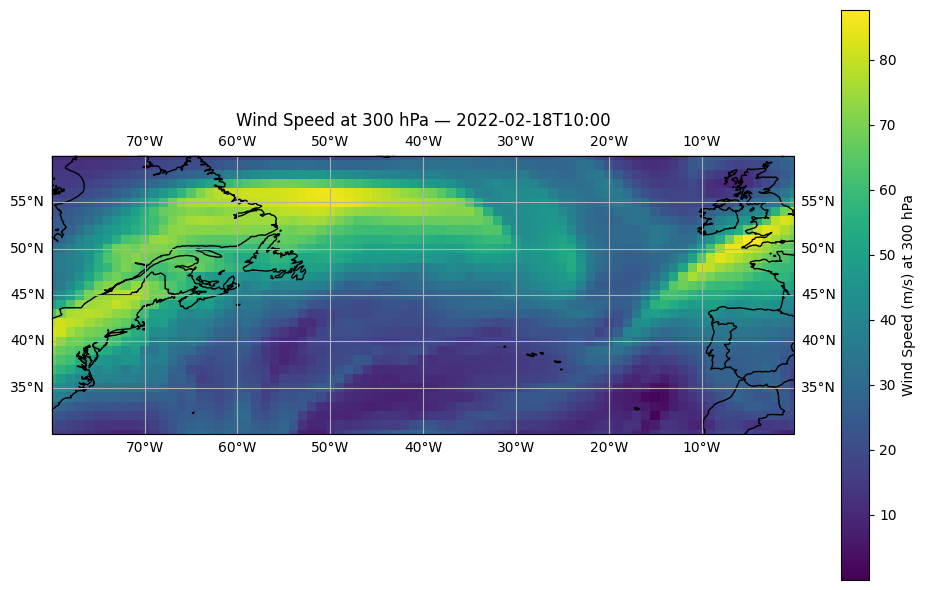

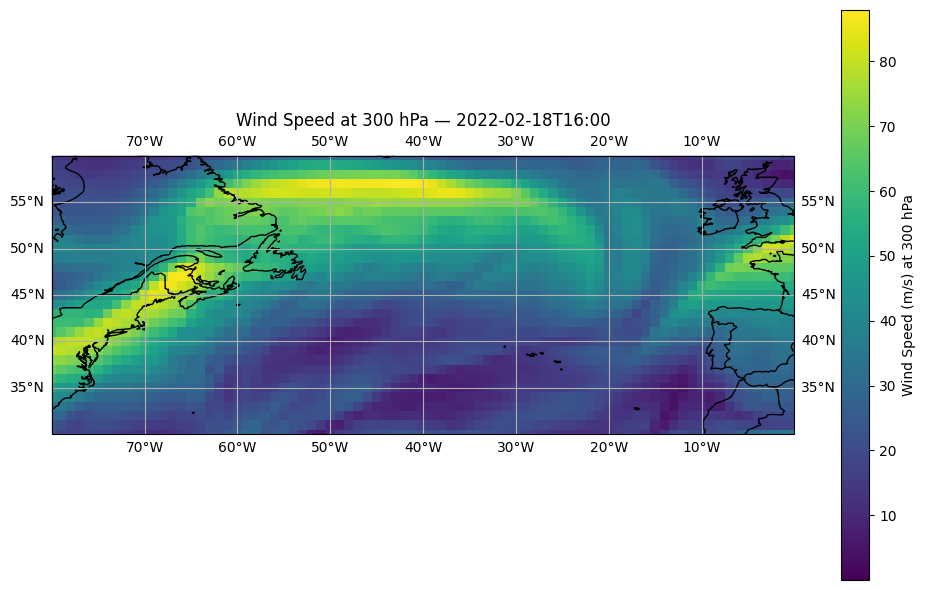

In [5]:
# === Define parameters ===
levels = [300]
times = [0, 1]  # 0 = 09:00 UTC, 1 = 15:00 UTC
zoom_extent = [-80, 0, 30, 60]  # North Atlantic

for time_idx in times:
    for level in levels:
        # === Wind Speed ===
        u = ds["u_component_of_wind"].sel(time=ds.time[time_idx], level=level)
        v = ds["v_component_of_wind"].sel(time=ds.time[time_idx], level=level)
        wind_speed = np.sqrt(u**2 + v**2)

        plt.figure(figsize=(10, 6))
        ax = plt.axes(projection=ccrs.PlateCarree())
        wind_speed.plot(ax=ax, cmap="viridis", cbar_kwargs={"label": f"Wind Speed (m/s) at {level} hPa"})
        ax.set_title(f"Wind Speed at {level} hPa — {str(ds.time[time_idx].values)[:16]}")
        ax.coastlines()
        ax.add_feature(cfeature.BORDERS)
        ax.gridlines(draw_labels=True)
        ax.set_extent(zoom_extent, crs=ccrs.PlateCarree())
        plt.tight_layout()
        plt.show()


## Find Exact Position of Storm Core for Selected Times

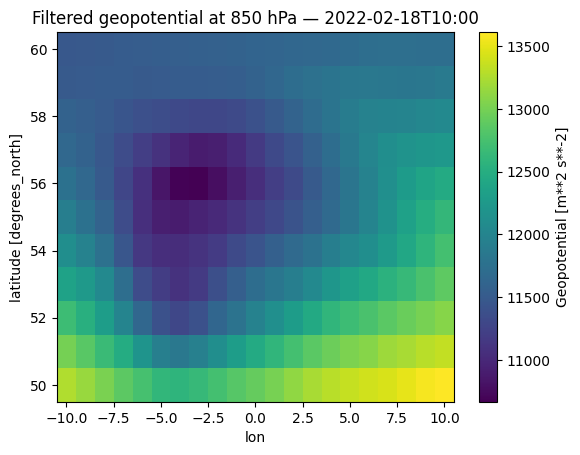

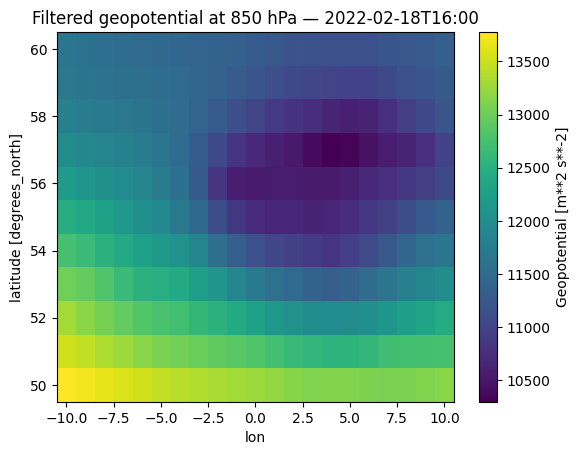

,Latitude,Longitude
2022-02-18T10:00,60.0,-6.0
2022-02-18T16:00,60.0,-7.0


In [9]:
# Time and level settings
times = [0, 1]
time_labels = [str(ds.time[t].values)[:16] for t in times]
level = 850  # hPa

storm_centers = {}

for t_idx, label in zip(times, time_labels):
    # Extract geopotential and fix longitude to -180 to 180
    geopot = ds["geopotential"].sel(time=ds.time[t_idx], level=level)
    geopot = geopot.assign_coords(lon=(((geopot.lon + 180) % 360) - 180))
    
    # Apply correct slicing AFTER remapping
    geopot = geopot.sortby('lon')  # Very important for proper slicing
    geopot = geopot.where(
        (geopot.lat >= 50) & (geopot.lat <= 60) &
        (geopot.lon >= -10) & (geopot.lon <= 10),
        drop=True
    )
    
    # Optional: plot the filtered data to verify visually
    geopot.plot()
    plt.title(f"Filtered geopotential at 850 hPa — {label}")
    plt.show()
    
    # Get storm center from minimum geopotential
    min_idx = np.unravel_index(np.argmin(geopot.values), geopot.shape)
    lat_min = geopot.isel(lat=min_idx[0], lon=min_idx[1]).lat.item()
    lon_min = geopot.isel(lat=min_idx[0], lon=min_idx[1]).lon.item()

    storm_centers[label] = (lat_min, lon_min)

# Display storm core locations
storm_centers_df = pd.DataFrame.from_dict(storm_centers, orient='index', columns=['Latitude', 'Longitude'])
storm_centers_df


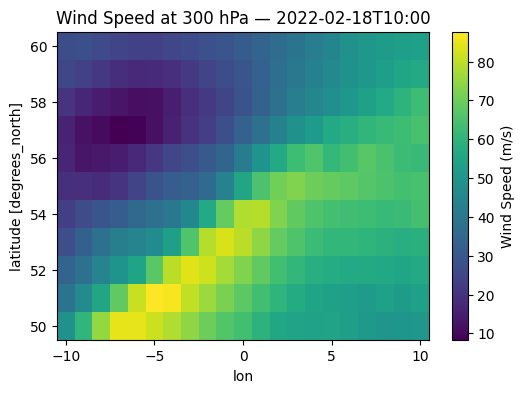

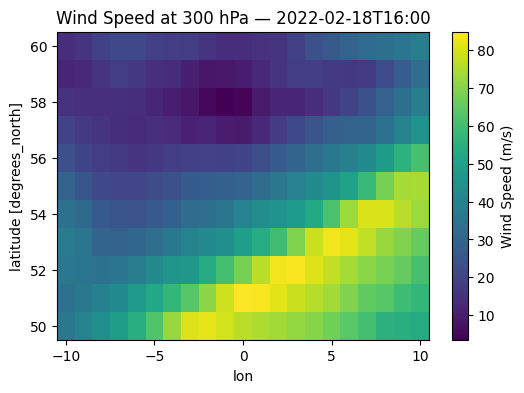

,Latitude,Longitude
2022-02-18T10:00,60.0,-10.0
2022-02-18T16:00,60.0,-10.0


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Time and level settings
times = [0, 1]
time_labels = [str(ds.time[t].values)[:16] for t in times]
level = 300  # pressure level in hPa

storm_centers = {}

for t_idx, label in zip(times, time_labels):
    # 1) Extract u and v components at this time+level, drop batch if present
    u = ds["u_component_of_wind"].sel(time=ds.time[t_idx], level=level).squeeze("batch")
    v = ds["v_component_of_wind"].sel(time=ds.time[t_idx], level=level).squeeze("batch")

    # 2) Compute wind speed
    wind = np.sqrt(u**2 + v**2)

    # 3) Remap lon coords from 0–360 to –180–+180
    wind = wind.assign_coords(
        lon = (((wind.lon + 180) % 360) - 180)
    ).sortby("lon")

    # 4) Subset to your box (50–60° N, –10–+10° E)
    wind_sel = wind.where(
        (wind.lat >= 50) & (wind.lat <= 60) &
        (wind.lon >= -10) & (wind.lon <= 10),
        drop=True
    )

    # 5) Plot
    plt.figure(figsize=(6,4))
    im = wind_sel.plot(
        cmap="viridis",
        add_colorbar=True,
        cbar_kwargs={"label": "Wind Speed (m/s)"},
    )
    plt.title(f"Wind Speed at {level} hPa — {label}")
    plt.show()

    # 6) (Optional) find “storm center” as min geopotential — if you still want that,
    #    you can re-extract geopotential just for the argmin:
    phi = ds["geopotential"].sel(time=ds.time[t_idx], level=level).squeeze("batch")
    phi = phi.assign_coords(lon=(((phi.lon + 180) % 360)-180)).sortby("lon")
    phi_sel = phi.where(
        (phi.lat >= 50)&(phi.lat <= 60)&(phi.lon >= -10)&(phi.lon <= 10),
        drop=True
    )
    min_idx = np.unravel_index(np.argmin(phi_sel.values), phi_sel.shape)
    lat_min = float(phi_sel.lat.values[min_idx[0]])
    lon_min = float(phi_sel.lon.values[min_idx[1]])
    storm_centers[label] = (lat_min, lon_min)

# Turn your storm-centers dict into a nice DataFrame
import pandas as pd
storm_centers_df = pd.DataFrame.from_dict(
    storm_centers, orient="index", columns=["Latitude", "Longitude"]
)
storm_centers_df


## Empty Maps

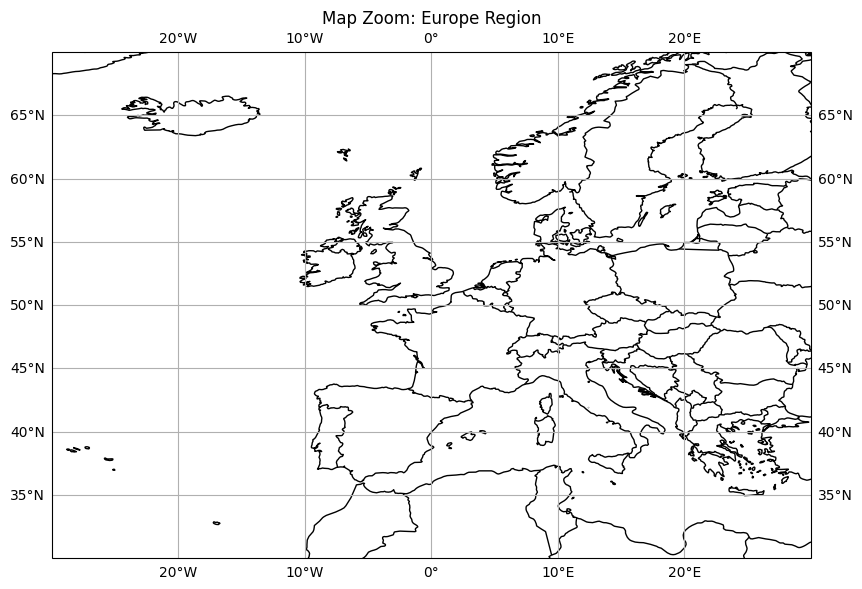

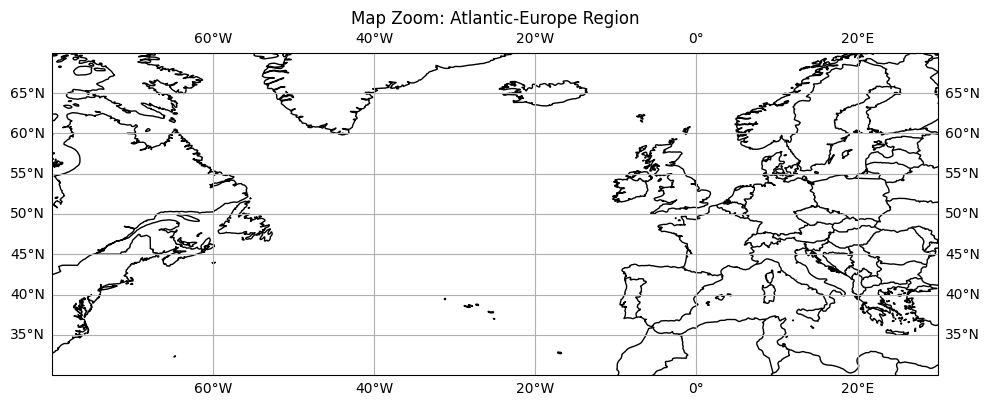

In [6]:
# Define the two zoom extents
zoom_extents = [
    ([-30, 30, 30, 70], "Europe Region"),
    ([-80, 30, 30, 70], "Atlantic-Europe Region")
]

# Generate maps
for extent, title in zoom_extents:
    plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.gridlines(draw_labels=True)
    ax.set_title(f"Map Zoom: {title}")
    plt.tight_layout()
    plt.show()
